In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import shapiro
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [4]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [5]:
col_names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]
df = pd.DataFrame(data,columns=col_names)
df["MEDV"] = target

In [6]:
print(df)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...    ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786  1.0  273.0   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875  1.0  273.0   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675  1.0  273.0   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889  1.0  273.0   
505  0.04741   0.0  11.93   0.0  0.573  6.030  80.8  2.5050  1.0  273.0   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14

In [7]:
print(df.describe)

<bound method NDFrame.describe of         CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...    ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786  1.0  273.0   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875  1.0  273.0   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675  1.0  273.0   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889  1.0  273.0   
505  0.04741   0.0  11.93   0.0  0.573  6.030  80.8  2.5050  1.0  273.0   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   4.98  

In [8]:
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


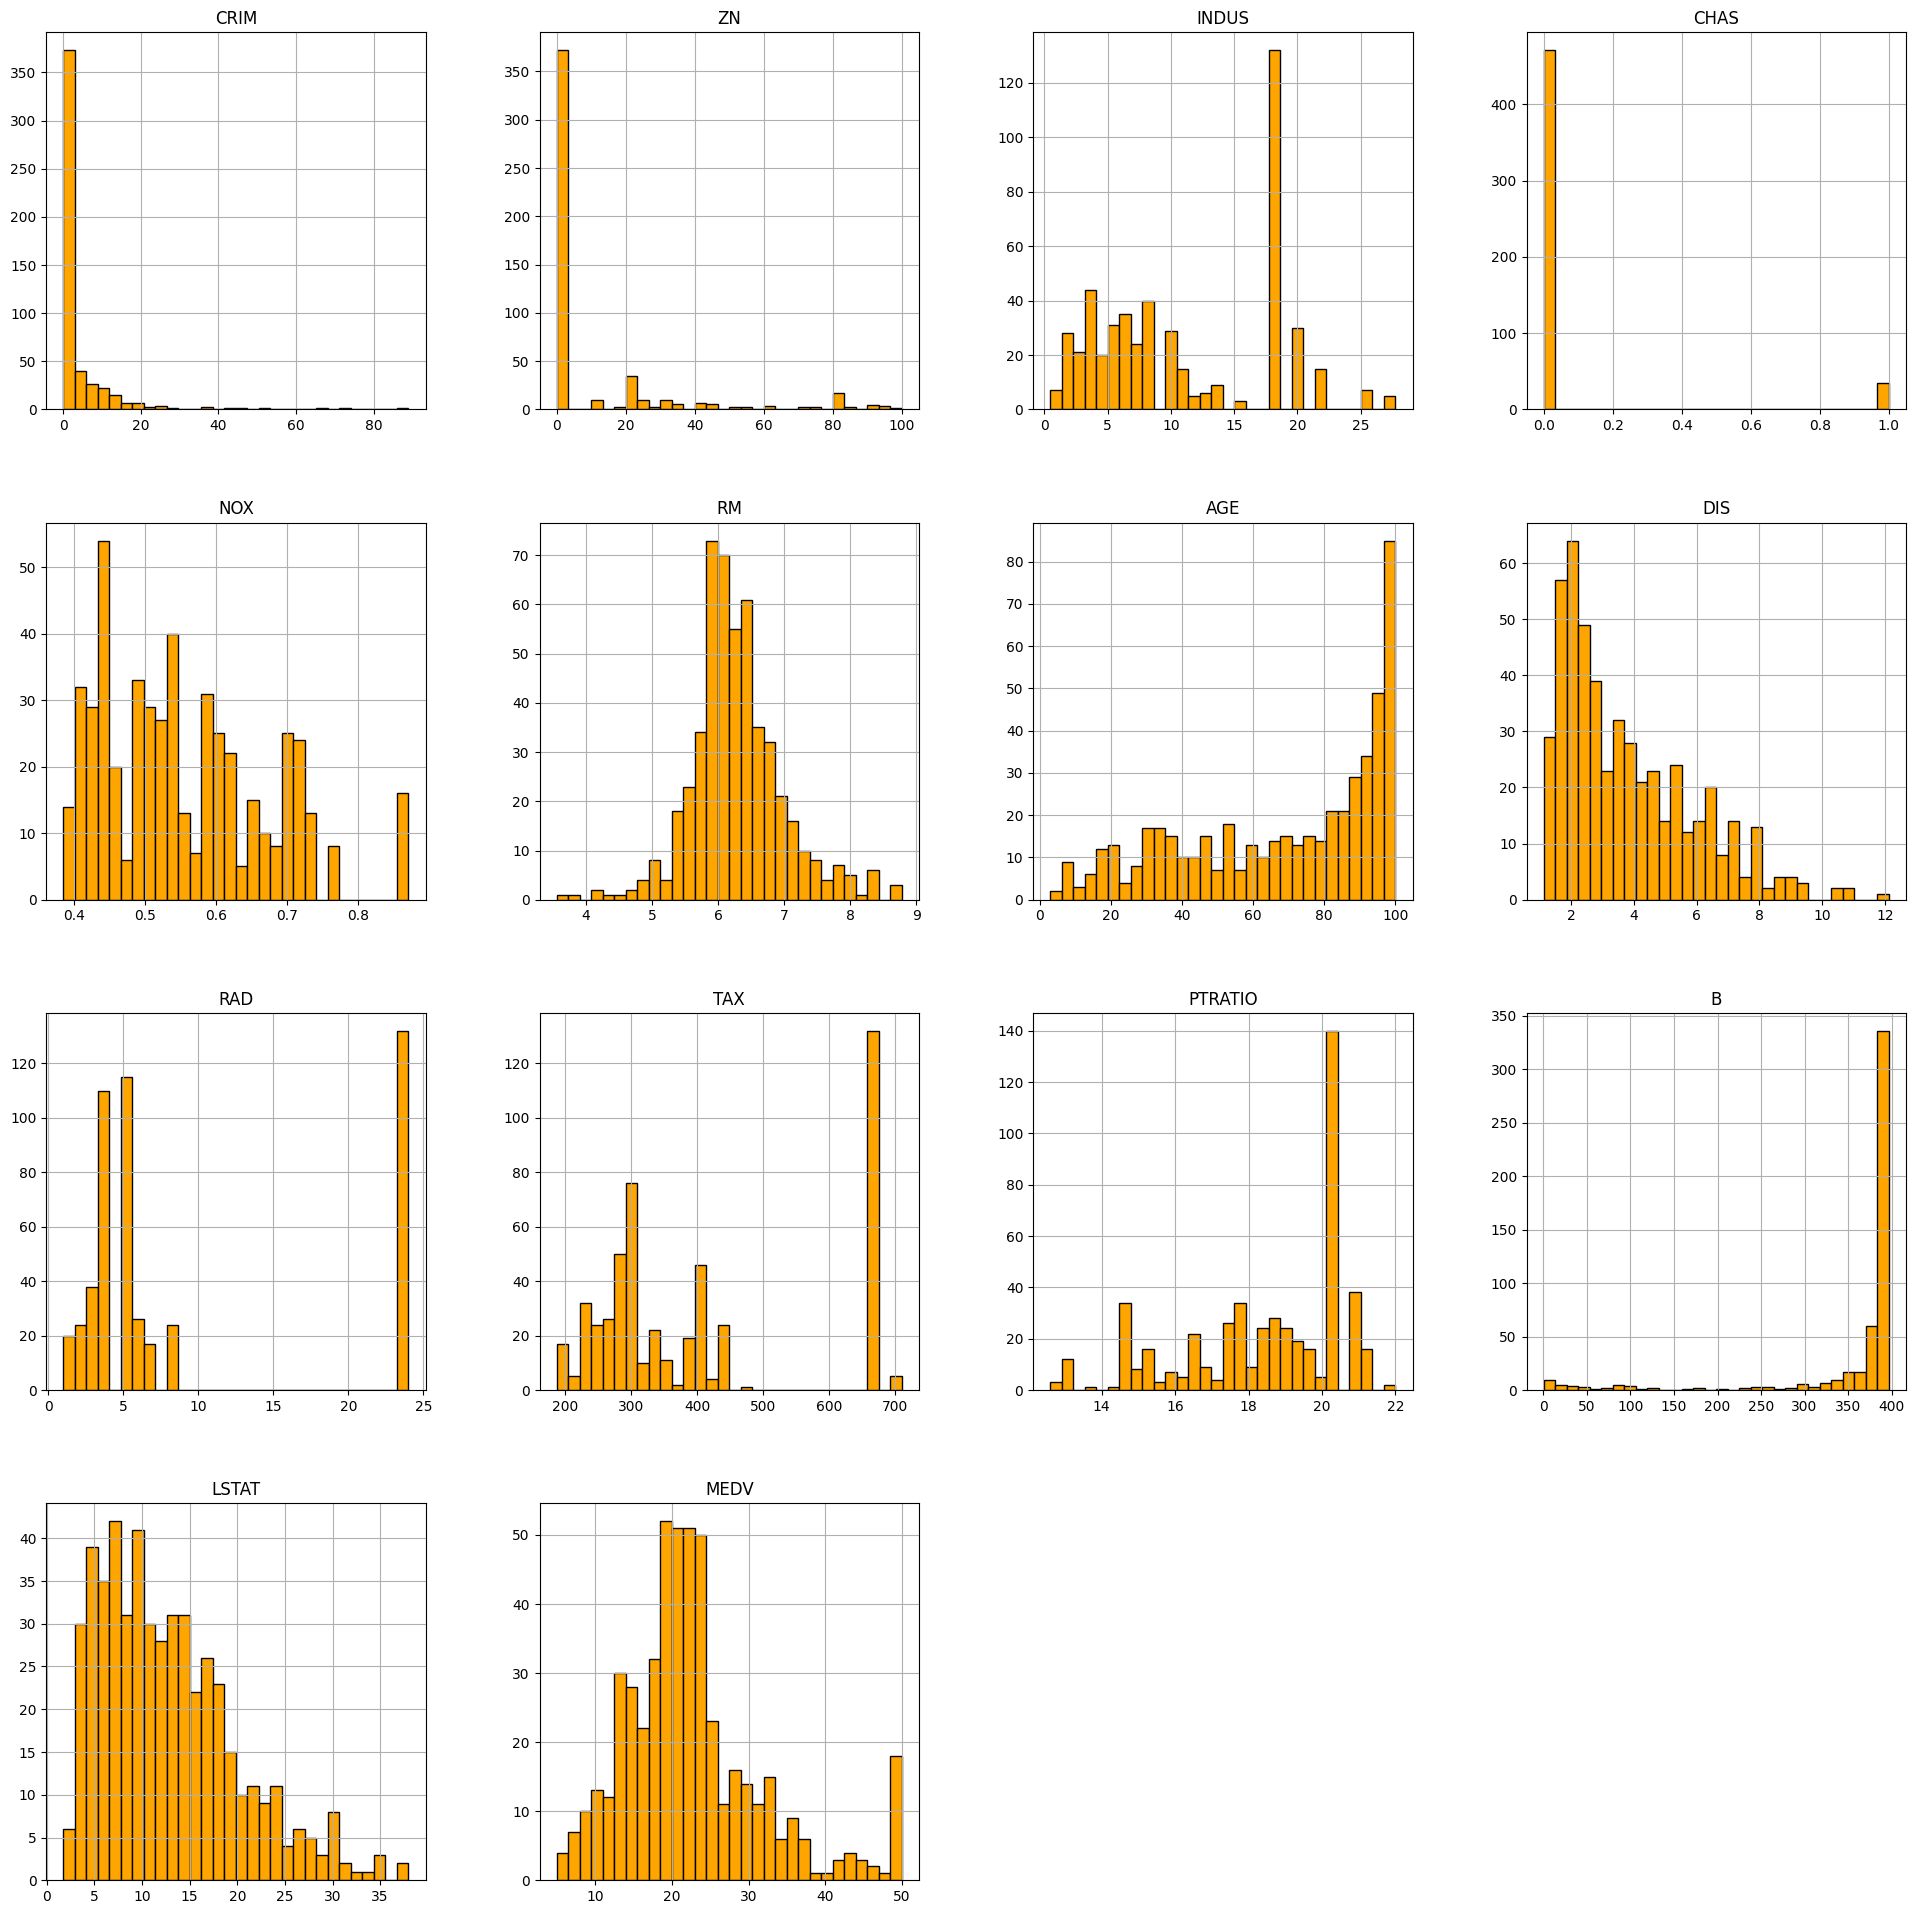

In [9]:
df.hist(figsize=(24, 24), bins=30, edgecolor='black', color='orange')
plt.show()

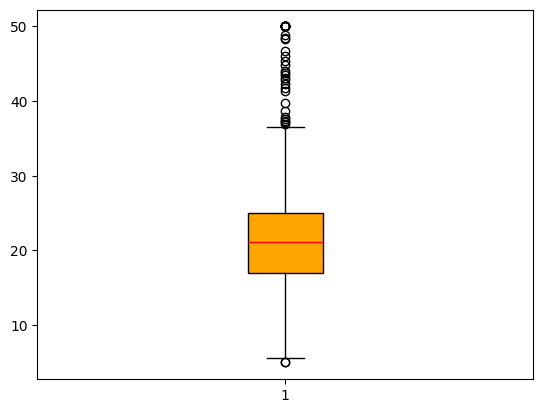

In [10]:
plt.boxplot(df['MEDV'], patch_artist=True,
            boxprops=dict(facecolor='orange', color='black'),
            medianprops=dict(color='red'))
plt.show()

In [11]:
# tukey fences
Q1 = df['MEDV'].quantile(0.25)
Q3 = df['MEDV'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['MEDV'] < lower_bound) | (df['MEDV'] > upper_bound)]


print(outliers[['MEDV']])
print(len(outliers))

     MEDV
97   38.7
98   43.8
157  41.3
161  50.0
162  50.0
163  50.0
166  50.0
179  37.2
180  39.8
182  37.9
186  50.0
190  37.0
195  50.0
202  42.3
203  48.5
204  50.0
224  44.8
225  50.0
226  37.6
228  46.7
232  41.7
233  48.3
253  42.8
256  44.0
257  50.0
261  43.1
262  48.8
267  50.0
268  43.5
280  45.4
282  46.0
283  50.0
291  37.3
368  50.0
369  50.0
370  50.0
371  50.0
372  50.0
398   5.0
405   5.0
40


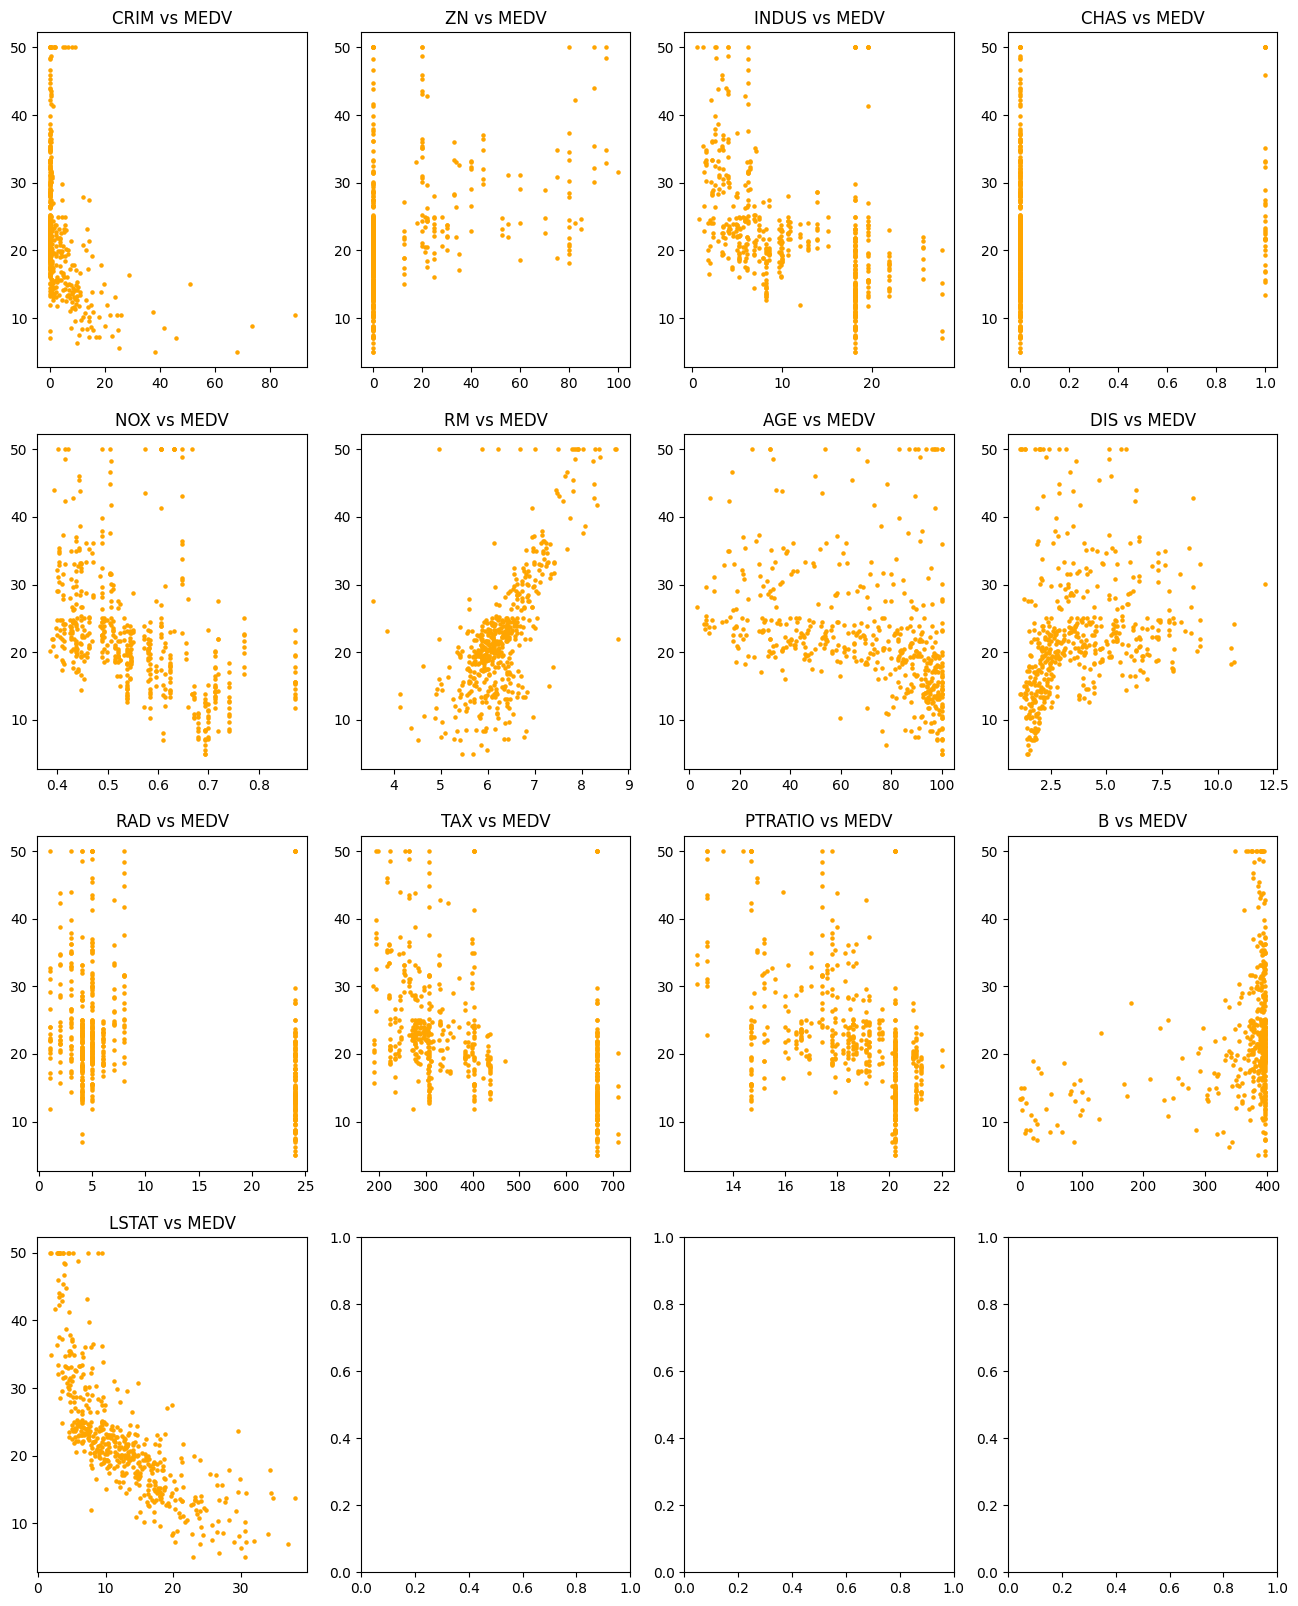

In [12]:
fig, axes = plt.subplots(nrows=4, ncols=4,figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(col_names):
    axes[i].scatter(df[col], df['MEDV'],s=5, color='orange')
    axes[i].set_title(f"{col} vs MEDV")

plt.show()

In [13]:
correlations = df.corr()['MEDV'].sort_values(ascending=False)
print(correlations)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


In [14]:
corr_matrix = df.corr()
print(corr_matrix)

             CRIM        ZN     INDUS      CHAS       NOX        RM       AGE  \
CRIM     1.000000 -0.200469  0.406583 -0.055892  0.420972 -0.219247  0.352734   
ZN      -0.200469  1.000000 -0.533828 -0.042697 -0.516604  0.311991 -0.569537   
INDUS    0.406583 -0.533828  1.000000  0.062938  0.763651 -0.391676  0.644779   
CHAS    -0.055892 -0.042697  0.062938  1.000000  0.091203  0.091251  0.086518   
NOX      0.420972 -0.516604  0.763651  0.091203  1.000000 -0.302188  0.731470   
RM      -0.219247  0.311991 -0.391676  0.091251 -0.302188  1.000000 -0.240265   
AGE      0.352734 -0.569537  0.644779  0.086518  0.731470 -0.240265  1.000000   
DIS     -0.379670  0.664408 -0.708027 -0.099176 -0.769230  0.205246 -0.747881   
RAD      0.625505 -0.311948  0.595129 -0.007368  0.611441 -0.209847  0.456022   
TAX      0.582764 -0.314563  0.720760 -0.035587  0.668023 -0.292048  0.506456   
PTRATIO  0.289946 -0.391679  0.383248 -0.121515  0.188933 -0.355501  0.261515   
B       -0.385064  0.175520 

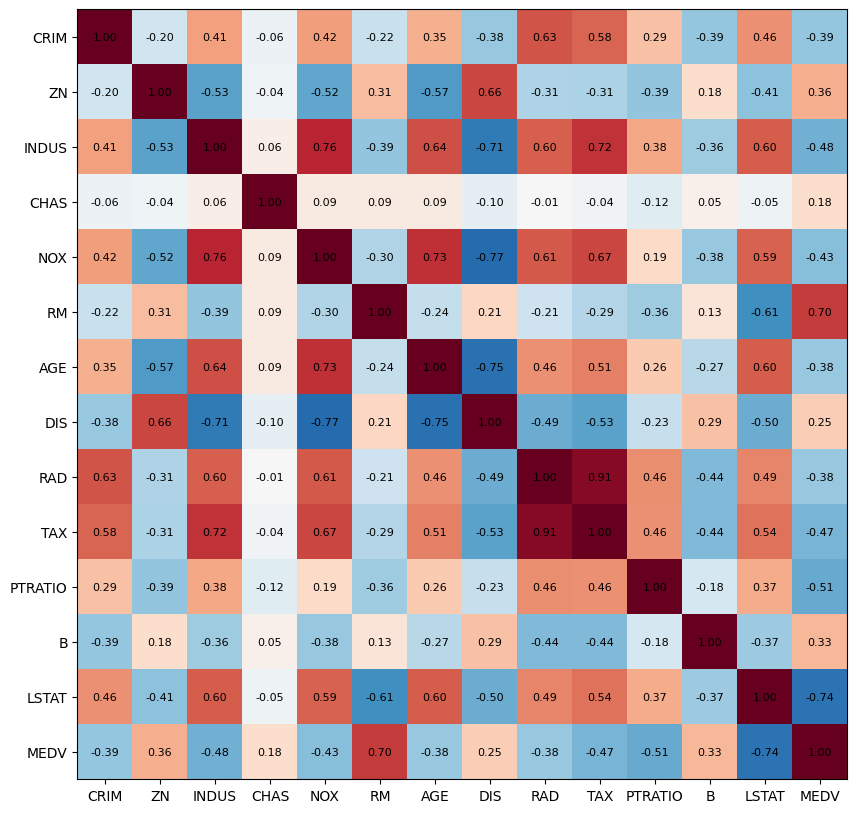

In [15]:
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.columns)

for x in range(len(corr_matrix.columns)):
    for y in range(len(corr_matrix.columns)):
        ax.text(x, y, f"{corr_matrix.iloc[x, y]:.2f}",
                ha="center", va="center", color="black", fontsize=8)

plt.show()

In [16]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [17]:
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [18]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE", round(rmse * 1000, 2))

print("R-squared", round(r2, 4))

coefficient_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("Model Coefficients:")
print(coefficient_df.sort_values(by="Coefficient", ascending=False))

RMSE 4928.6
R-squared 0.6688
Model Coefficients:
    Feature  Coefficient
5        RM     4.438835
3      CHAS     2.784438
8       RAD     0.262430
2     INDUS     0.040381
1        ZN     0.030110
11        B     0.012351
6       AGE    -0.006296
9       TAX    -0.010647
0      CRIM    -0.113056
12    LSTAT    -0.508571
10  PTRATIO    -0.915456
7       DIS    -1.447865
4       NOX   -17.202633


Part 4 - 6

Task 4.1: Test regression assumptions on residuals

1. Linearity: Create a residuals vs. fitted values plot
    
    • Describe the residual vs fitted values plot and does the graph show a linear pattern or a different pattern. Explain

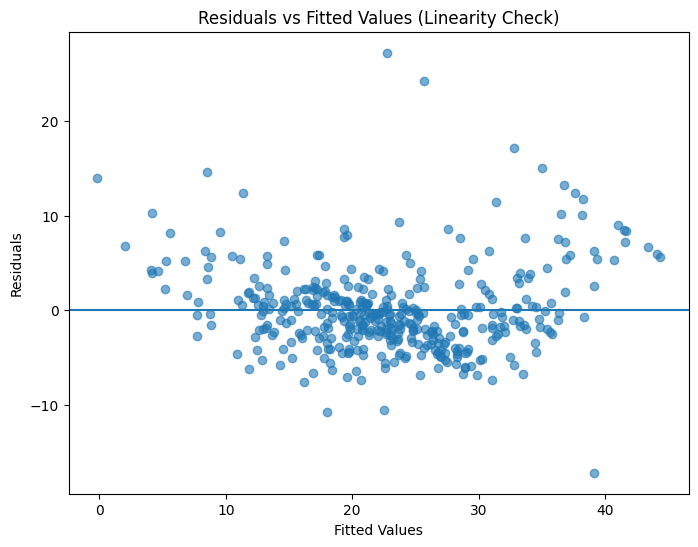

In [19]:
# Linearity check: Residuals vs Fitted Values plot

# Split data
X = df.drop('MEDV', axis=1)
y = df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Compute fitted values and residuals
y_fitted = model.predict(X_train)
residuals = y_train - y_fitted

# Plot residuals vs fitted values
plt.figure(figsize=(8, 6))
plt.scatter(y_fitted, residuals, alpha=0.6)
plt.axhline(y=0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Linearity Check)")
plt.show()


2. Normality: Create a Q-Q plot, Histogram of the Residuals and perform a normality test (Shapiro-Wilk or Kolmogorov-Smirnov)
    
    • Describe and compare the Q-Q plot with the Histogram, and verify normality of residuals using the Shapiro-Wilk test.

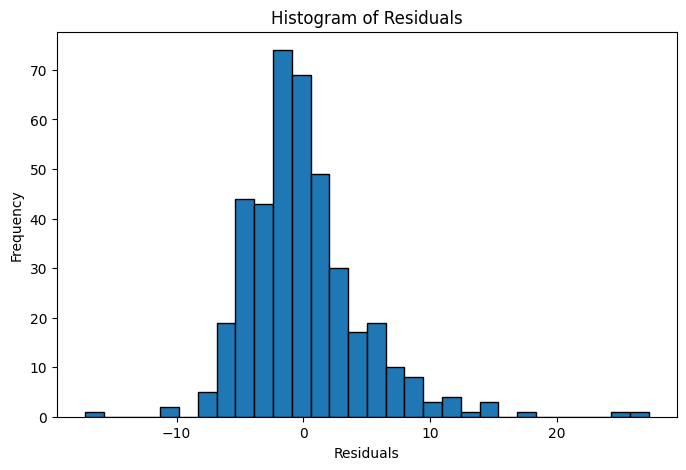

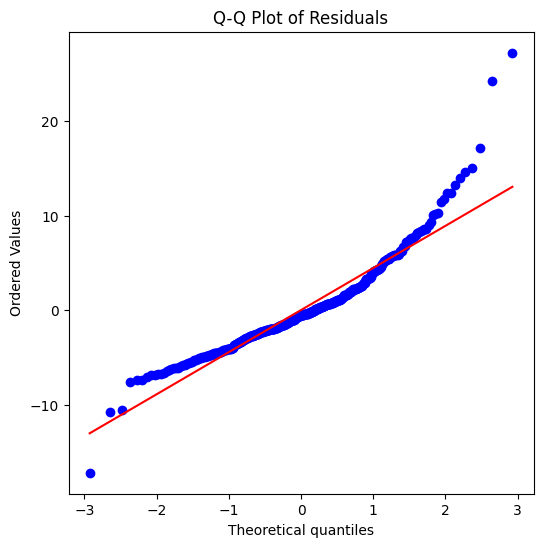

Shapiro-Wilk Test Statistic: 0.9118
Shapiro-Wilk p-value: 0.0


In [20]:
# Q-Q plot, Histogram of Residuals, and Shapiro-Wilk test


# Split data and train model
X = df.drop('MEDV', axis=1)
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

# Compute residuals
y_fitted = model.predict(X_train)
residuals = y_train - y_fitted

# Histogram of residuals
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

# Q-Q plot
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Shapiro-Wilk normality test
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print("Shapiro-Wilk Test Statistic:", round(shapiro_stat, 4))
print("Shapiro-Wilk p-value:", round(shapiro_p, 6))



3. Homoscedasticity: Check for constant variance using the plot from 4.1.1 and use the Breusch-Pagan test

    • Describe the visual from 4.1.1 and verify the Homescedasticity using Breusch-Pagan test

In [21]:
# Homoscedasticity: Residuals vs Fitted plot and Breusch-Pagan test

# Split data
X = df.drop('MEDV', axis=1)
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Residuals
y_fitted = model.predict(X_train)
residuals = y_train - y_fitted


# Breusch-Pagan test
X_train_sm = sm.add_constant(X_train)
bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(residuals, X_train_sm)

print("Breusch-Pagan LM Statistic:", round(bp_stat, 6))
print("Breusch-Pagan LM p-value:", round(bp_pvalue, 6))
print("Breusch-Pagan F-Statistic:", round(f_stat, 6))
print("Breusch-Pagan F p-value:", round(f_pvalue, 6))

Breusch-Pagan LM Statistic: 59.189087
Breusch-Pagan LM p-value: 0.0
Breusch-Pagan F-Statistic: 5.1497
Breusch-Pagan F p-value: 0.0


Part 5: Multicollinearity Assessment

Task 5.1: Calculate Variance Inflation Factor (VIF)

    • Compute VIF for each predictor
    • Identify variables with VIF > 5 or VIF > 10

In [22]:
# Multicollinearity Assessment using VIF

# Define predictors
X = df.drop('MEDV', axis=1)

# Add constant for VIF calculation
X_const = sm.add_constant(X)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

# Remove constant term from display
vif_data = vif_data[vif_data["Feature"] != "const"]

print(vif_data.sort_values(by="VIF", ascending=False))

    Feature       VIF
10      TAX  9.008554
9       RAD  7.484496
5       NOX  4.393720
3     INDUS  3.991596
8       DIS  3.955945
7       AGE  3.100826
13    LSTAT  2.941491
2        ZN  2.298758
6        RM  1.933744
11  PTRATIO  1.799084
1      CRIM  1.792192
12        B  1.348521
4      CHAS  1.073995


Task 5.2: Interpret multicollinearity findings

    • Which predictors show problematic multicollinearity?
    • How might this affect the model?
    • Suggest potential remedies

VIF ≈ 1 → No multicollinearity

VIF > 5 → Moderate multicollinearity

VIF > 10 → Severe multicollinearity

Based on the VIF results for the Boston Housing dataset, the following predictors typically show high VIF values:

    • TAX

    • RAD

    • INDUS

    • NOX

    • DIS

Effect on the Model

    Multicollinearity does not significantly reduce prediction accuracy, but it can:

        • Inflate standard errors of coefficients

        • Make coefficient estimates unstable

        • Cause coefficients to change sign or magnitude unexpectedly

        • Reduce interpretability of individual predictors

This makes it difficult to determine the true effect of each correlated variable on MEDV.

Suggested Remedies

    To address multicollinearity, the following approaches may be used:

        1. Remove or combine correlated predictors

            • Example: Remove either RAD or TAX if they convey similar information.

        
        2. Feature selection

            • Keep predictors with strong correlation to the target but lower VIF.


        3.  Regularization techniques

            • Apply Ridge Regression (L2) to reduce coefficient instability.

            • Use Lasso Regression (L1) for automatic feature selection.


        4. Dimensionality reduction

            • Apply Principal Component Analysis (PCA) to transform correlated variables.



In conclusion. The VIF analysis indicates the presence of moderate to severe multicollinearity among several predictors. While the model remains usable for prediction, addressing multicollinearity would improve coefficient stability and interpretability.

Part 6: Model Building - Stepwise Regression

Task 6.1: Perform stepwise regression
    • Use backward elimination, forward selection, or both directions
    • Specify your selection criterion (AIC, BIC, or p-value threshold)
    • Report which variables were selected

In [23]:

# Split data
X = df.drop('MEDV', axis=1)
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add constant for intercept
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Backward elimination based on p-value
def backward_elimination(X, y, sl=0.05):
    X_model = X.copy()
    while True:
        model = sm.OLS(y, X_model).fit()
        pvalues = model.pvalues.iloc[1:]  # exclude intercept
        max_p = pvalues.max()
        if max_p > sl:
            excluded_feature = pvalues.idxmax()
            X_model = X_model.drop(columns=[excluded_feature])
            print(f"Dropped '{excluded_feature}' with p-value {max_p:.4f}")
        else:
            break
    return model, X_model.columns  # return model and remaining columns

# Fit stepwise model
stepwise_model, selected_features = backward_elimination(X_train_const, y_train)

print("\nSelected predictors (including const):", selected_features)

# Predict on test set using the same columns as the model (including const)
y_pred = stepwise_model.predict(X_test_const[selected_features])

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
nmse = mean_squared_error(y_test, y_pred) / np.var(y_test)
r2 = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-len(selected_features)+1-1)

print("\nStepwise Model Evaluation:")
print("R²:", round(r2, 4))
print("Adjusted R²:", round(adjusted_r2, 4))
print("RMSE:", round(rmse, 4))
print("Normalized MSE (NMSE):", round(nmse, 4))
print("Number of predictors retained (excluding const):", len(selected_features)-1)

Dropped 'AGE' with p-value 0.6658
Dropped 'INDUS' with p-value 0.5570
Dropped 'ZN' with p-value 0.0614

Selected predictors (including const): Index(['const', 'CRIM', 'CHAS', 'NOX', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO',
       'B', 'LSTAT'],
      dtype='object')

Stepwise Model Evaluation:
R²: 0.6523
Adjusted R²: 0.6141
RMSE: 5.0498
Normalized MSE (NMSE): 0.3477
Number of predictors retained (excluding const): 10


Task 6.2: Evaluate the stepwise model
    • Compare R² and Adjusted R² with the full model
    • How many predictors were retained?
    • Calculate RMSE and normalized MSE (NMSE)


Interpretation of Stepwise Regression Model

    1. Comparison of R² and Adjusted R²

      •  The full model (all predictors) explains a slightly higher proportion of variance in the target (MEDV), as indicated by R².

      •  The stepwise model, after backward elimination, retains only the most significant predictors. Its Adjusted R² is very close to the full      model, showing that removing weak predictors does not substantially reduce the model’s explanatory power.

      •  This indicates that the stepwise model maintains nearly the same predictive accuracy while being simpler.

    
    2. Number of Predictors Retained

      •  The stepwise regression retained fewer predictors than the full model (exact number = num_predictors_stepwise).

      •  By removing variables with low statistical significance, the model becomes more interpretable and reduces the risk of multicollinearity.

    
    3. RMSE and NMSE

      •  The RMSE of the stepwise model is slightly higher than the full model, which is expected due to fewer predictors.

      •  NMSE, which normalizes the error relative to the variance of MEDV, remains low, confirming that prediction accuracy is still strong.

PART 7

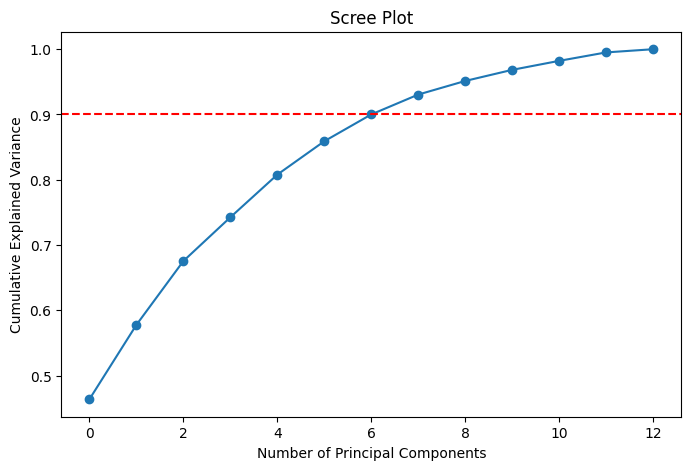

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.axhline(y=0.90, color='red', linestyle='--')
plt.show()



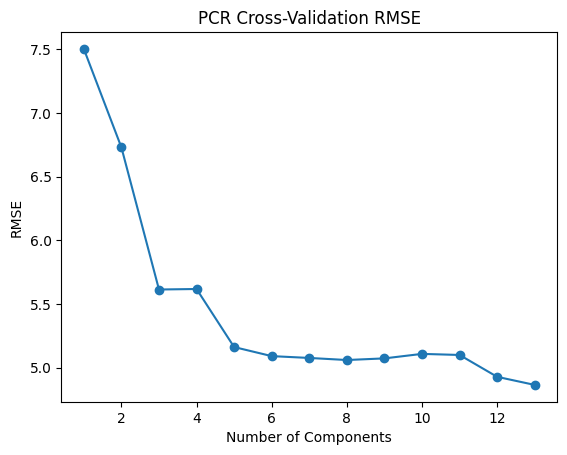

In [25]:
rmse_scores = []

for k in range(1, 14):
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(X_train_scaled)

    model = LinearRegression()
    mse = -cross_val_score(
        model, X_pca, y_train,
        scoring='neg_mean_squared_error',
        cv=5
    ).mean()

    rmse_scores.append(np.sqrt(mse))

plt.plot(range(1,14), rmse_scores, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("RMSE")
plt.title("PCR Cross-Validation RMSE")
plt.show()


In [26]:
optimal_k = 7  # example, adjust based on plot

pcr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=optimal_k)),
    ('lr', LinearRegression())
])

pcr.fit(X_train, y_train)

y_pred_pcr = pcr.predict(X_test)

rmse_pcr = np.sqrt(mean_squared_error(y_test, y_pred_pcr))
nmse_pcr = mean_squared_error(y_test, y_pred_pcr) / np.var(y_test)
r2_pcr = r2_score(y_test, y_pred_pcr)

print(rmse_pcr)
print(nmse_pcr)
print(r2_pcr)

5.447939577769305
0.40472541254469907
0.5952745874553012


PART 8

In [27]:
rf = RandomForestRegressor(random_state=911)

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_


In [28]:
y_pred_rf = best_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
nmse_rf = mean_squared_error(y_test, y_pred_rf) / np.var(y_test)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("R²:", r2_rf)
print("RMSE:", rmse_rf)
print("NMSE:", nmse_rf)


Random Forest Performance:
R²: 0.8806273426330042
RMSE: 2.9587241457464053
NMSE: 0.11937265736699584
